# Milestone 2 — Reproducible Experimental Study of Clustering

**Unsupervised Learning Project · 2025/2026 · Hotel Booking Demand**

| | |
|---|---|
| **Team** | Group 3 — P2: Rogério Soares (73803), Guilherme Simões (74154), Vasco Horta (73476) |
| **Project title** | Unsupervised Clustering of Hotel Bookings: Segmenting Business and Leisure Travellers Based on Booking Characteristics |
| **Checkpoint date** | 30 April 2026 |
| **Repository** | _[fill in: GitHub URL]_ |
| **Repository version shown in lab** | _[fill in: commit hash / tag / branch]_ |

---

This notebook is the Milestone 2 deliverable. It is structured to follow the **seven sections** of the project template, with the appendix tables and figures inlined. All heavy preprocessing logic is reproduced here (or imported from the project's modules) so the notebook is self-contained.

## 1. RQ1 and segmentation time

### 1.1 Project title

**Unsupervised Clustering of Hotel Bookings: Segmenting Business and Leisure Travellers Based on Booking Characteristics** (Group 3 — P2; Project Specification Section 1).

### 1.2 RQ1 — segmentation question (reframed)

**Original framing (Project Specification, Section 3):** *"Segment hotel guests into travel-purpose clusters... to identify if natural business or leisure patterns emerge from booking data."*

**Reframed for this milestone (per instructor feedback on the specification, point 1).** *Discover booking-pattern profiles from booking-time information alone, and assess — post-hoc — which (if any) of the resulting profiles correspond to recognisable business-like or leisure-like behaviour.* This wording is more faithful to the unsupervised setting (we have no labels) and avoids presupposing the existence of a clean business/leisure dichotomy in the data.

In two lines: *Can hotel bookings be partitioned into stable, interpretable profiles using features known at booking creation, in a way that supports tailored revenue and pricing strategies — and do any of these profiles plausibly capture leisure-vs-business travel patterns?*

### 1.3 Unit of analysis

One row = **one booking record** (Project Specification Section 3). The same guest may appear in multiple rows; bookings, not unique guests, are the entities being clustered.

### 1.4 Segmentation time (index time)

All clustering inputs are restricted to information available **at booking creation**. Variables that materialise after booking (`is_canceled`, `reservation_status`, `reservation_status_date`) are *post-hoc profiling variables* — they describe what happens to a booking after it is placed and are never seen by the clustering algorithm. Variables that evolve between booking creation and arrival (`assigned_room_type`, `days_in_waiting_list`) are also excluded for the same reason; the instructor flagged `reserved_room_type` as the booking-time-correct alternative to `assigned_room_type` (feedback point 3).

### 1.5 Why this reframe matters for the project

The reframe propagates into three concrete decisions documented later in this notebook:

1. **Feature audit (Section 4.1).** Every retained feature is checked against the index-time rule; two features (`assigned_room_type`, `days_in_waiting_list`) are dropped on this basis (feedback point 3).
2. **Clustering inputs vs profiling variables (Section 3.3, Section 4.2).** Outcome variables are partitioned into a separate `df_labels` frame and used only for post-hoc cluster description, not for fitting (feedback point 4).
3. **Cautious cluster narrative (Section 5.8).** When we describe the clusters we report what they *contain* and only then offer business-/leisure-like *interpretation* as a hypothesis — the description is the result, the labelling is post-hoc commentary.

### 1.6 Empirical context and the two-dataset decision

Our EDA (Milestone 1 notebook) showed that the City vs Resort hotel split has small numerical effect sizes (max |Cohen's d| = 0.47 across the audit features), but clearer differences in categorical composition (notably `market_segment`). This is *good news* for the reframed RQ: the dominant variance direction is not the hotel partition, leaving room for cluster structure that may align with travel purpose.

**Per instructor feedback on Q2 ("hotel feature shows few differences between hotels — drop it; justify why we do not use it"), we build two datasets in this notebook:**

- **`rep_v1_with_hotel`** — keeps `hotel` as a clustering input. This is the milestone baseline used for all Section 5 experiments.
- **`rep_v3_no_hotel`** — drops `hotel` from the categorical block. Persisted as a candidate sensitivity dataset to be executed in the final report.

We proceed with experiments on `rep_v1_with_hotel` for this checkpoint (the prof's instruction was *"proceed with the experiments with the one dataset currently"*). The `rep_v3_no_hotel` dataset is materialised here so the v3 representation is available end-to-end, but its clustering runs are queued for the final.

## 2. Dataset version control and documentation

- **Course release used:** `hotel_bookings_course_release_v1.csv`
- **Original source:** Kaggle — [jessemostipak/hotel-booking-demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand/data)
- **Reference:** António, N., de Almeida, A., & Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41–49. <https://doi.org/10.1016/j.dib.2018.11.126>
- **License / usage terms:** CC0 1.0 Public Domain (as stated in the course release). **Yes**, terms reviewed and compatible with academic reuse.
- **Time span:** Arrivals between July 2015 and August 2017, across two hotels (City Hotel and Resort Hotel).

**Known data-quality issues:**

- `children`: 4 NaN values
- `country`: ~0.4% missing values
- `agent` / `company`: NULL encoded as the literal string `"NULL"` (not a proper NaN)
- Some rows have 0 adults + 0 children + 0 babies (impossible — data-entry error)
- `adr` has at least one negative value and one extreme positive (~5400 €) — data-entry errors

The cell below records the SHA-256 fingerprint of the dataset file so that future runs can verify they are working with the same data.

In [25]:
import hashlib
from pathlib import Path

DATASET_PATH = 'hotel_bookings_course_release_v1.csv'

with open(DATASET_PATH, 'rb') as f:
    DATASET_SHA256 = hashlib.sha256(f.read()).hexdigest()

DATASET_SIZE_BYTES = Path(DATASET_PATH).stat().st_size

print(f'Dataset      : {DATASET_PATH}')
print(f'Size (bytes) : {DATASET_SIZE_BYTES:,}')
print(f'SHA-256      : {DATASET_SHA256}')

Dataset      : hotel_bookings_course_release_v1.csv
Size (bytes) : 16,855,599
SHA-256      : 7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06


### Imports and data loading

We reproduce the data-quality fixes from the Milestone 1 pipeline so this notebook is self-contained.

In [26]:
import os
import json
import time
import uuid
import warnings
from datetime import datetime, timezone
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score,
)
from sklearn.model_selection import train_test_split

# Project-local iK-means implementation (Mirkin's anomalous-pattern initialisation)
from modules.ikmeans.ikmeans import (
    APCluster, ikmeans_initialize,
    compute_feature_statistics,
)

warnings.filterwarnings('ignore')
np.set_printoptions(suppress=True, precision=4)

In [27]:
# Reused from main.ipynb (data loading + Section "Data Quality Fixes")
df_raw = pd.read_csv(DATASET_PATH)
print(f'Raw shape: {df_raw.shape}')

# --- Data quality fixes (from Milestone 1) ---
df = df_raw.copy()

# Fix 1: children NaN -> 0
df['children'] = df['children'].fillna(0).astype(int)

# Fix 2: drop impossible rows (0 adults + 0 children + 0 babies)
impossible_mask = (df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)
df = df.loc[~impossible_mask].copy()

# Fix 3: negative ADR -> NaN (will be median-imputed by the pipeline)
df.loc[df['adr'] < 0, 'adr'] = np.nan

# --- Outcome variables held aside for profiling ---
PROFILING_LABELS = ['is_canceled', 'reservation_status', 'reservation_status_date']
df_labels = df[PROFILING_LABELS].copy()
df = df.drop(columns=PROFILING_LABELS)

# --- ID-like columns and post-booking-time columns excluded from clustering ---
ID_LIKE = ['agent', 'company']
POST_BOOKING = ['assigned_room_type', 'days_in_waiting_list']  # not knowable at index time
df_features = df.drop(columns=ID_LIKE + POST_BOOKING).copy()

print(f'After data-quality fixes      : {df.shape}')
print(f'After holding out outcome+ID  : {df_features.shape}')

Raw shape: (119390, 32)
After data-quality fixes      : (119210, 29)
After holding out outcome+ID  : (119210, 25)


## 3. Completed Exploratory Data Analysis (EDA)

The full EDA — univariate distributions, pairwise associations, hotel split, seasonality, outlier visualisation — lives in the Milestone 1 notebook (`main.ipynb`). Here we report the artefacts the template asks for: a missingness summary, an outlier summary, the variables dropped before modelling, and the leakage exclusions.

### 3.1 Missingness summary by attribute type

In [28]:
# Reused from main.ipynb (Section "Missingness Report")
def missingness_table(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in frame.columns:
        n_missing = frame[col].isna().sum()
        # Treat literal "NULL" strings as missing for agent/company
        if col in ('agent', 'company'):
            n_missing += (frame[col].astype(str).str.upper() == 'NULL').sum()
        rows.append({
            'feature': col,
            'dtype': str(frame[col].dtype),
            'kind': 'numerical' if pd.api.types.is_numeric_dtype(frame[col]) else 'categorical',
            'n_missing': int(n_missing),
            'pct_missing': round(100 * n_missing / len(frame), 2),
        })
    out = pd.DataFrame(rows).sort_values('pct_missing', ascending=False).reset_index(drop=True)
    return out

miss = missingness_table(df_raw)
print('Missingness in the raw dataset (literal "NULL" counted as missing for agent/company):')
print(miss[miss['n_missing'] > 0].to_string(index=False))

print('\nSummary by kind:')
print(miss.groupby('kind')['n_missing'].agg(['sum', 'mean']).round(2).to_string())

Missingness in the raw dataset (literal "NULL" counted as missing for agent/company):
 feature   dtype        kind  n_missing  pct_missing
 company float64   numerical     112593        94.31
   agent float64   numerical      16340        13.69
 country     str categorical        488         0.41
children float64   numerical          4         0.00

Summary by kind:
                sum     mean
kind                        
categorical     488    40.67
numerical    128937  6446.85


### 3.2 Outlier summary (numerical, IQR method)

In [29]:
# Reused from main.ipynb (Section "Outlier Report (Numerical — IQR method)")
def iqr_outlier_table(frame: pd.DataFrame, num_cols: list[str]) -> pd.DataFrame:
    rows = []
    for col in num_cols:
        s = frame[col].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_low = int((s < lo).sum())
        n_high = int((s > hi).sum())
        rows.append({
            'feature': col,
            'min': round(s.min(), 2),
            'q1': round(q1, 2),
            'median': round(s.median(), 2),
            'q3': round(q3, 2),
            'max': round(s.max(), 2),
            'iqr': round(iqr, 2),
            'n_outliers_low': n_low,
            'n_outliers_high': n_high,
            'pct_outliers': round(100 * (n_low + n_high) / len(s), 2),
        })
    return pd.DataFrame(rows).sort_values('pct_outliers', ascending=False).reset_index(drop=True)

num_cols_eda = df_features.select_dtypes(include=[np.number]).columns.tolist()
outlier_summary = iqr_outlier_table(df_features, num_cols_eda)
print('Outlier summary (IQR rule, 1.5·IQR fences):')
print(outlier_summary.to_string(index=False))

Outlier summary (IQR rule, 1.5·IQR fences):
                       feature    min     q1  median     q3    max   iqr  n_outliers_low  n_outliers_high  pct_outliers
                        adults    0.0    2.0    2.00    2.0   55.0   0.0           23250             6280         24.77
               booking_changes    0.0    0.0    0.00    0.0   18.0   0.0               0            17978         15.08
                      children    0.0    0.0    0.00    0.0   10.0   0.0               0             8590          7.21
   required_car_parking_spaces    0.0    0.0    0.00    0.0    8.0   0.0               0             7409          6.22
        previous_cancellations    0.0    0.0    0.00    0.0   26.0   0.0               0             6479          5.43
                           adr    0.0   69.5   94.95  126.0 5400.0  56.5               0             3864          3.24
             is_repeated_guest    0.0    0.0    0.00    0.0    1.0   0.0               0             3755          3

### 3.3 Variables dropped before modelling

| Variable | Reason | Category |
|---|---|---|
| `is_canceled` | Outcome variable (known only post-booking) | **Leakage** — mandatory exclusion |
| `reservation_status` | Outcome variable (Check-Out / Canceled / No-Show) | **Leakage** — mandatory exclusion |
| `reservation_status_date` | Date of the outcome event | **Leakage** — mandatory exclusion |
| `assigned_room_type` | Determined at check-in, not at booking time | **Leakage-adjacent** — violates the index-time rule (Section 1) |
| `days_in_waiting_list` | Accumulates between booking creation and arrival | **Leakage-adjacent** — not stable at booking time |
| `agent` | High-cardinality identifier (~330 levels), ~13% encoded as "NULL" | ID-like, no semantic content |
| `company` | High-cardinality identifier, ~94% "NULL" | ID-like, near-degenerate |

The three leakage variables are retained in `df_labels` for **post-hoc profiling only** (e.g., reporting per-cluster cancellation rate after clustering is complete). They are never seen by the clustering algorithm. `assigned_room_type` and `days_in_waiting_list` are dropped entirely because their values are not knowable at booking-creation time, which is our declared segmentation time (Section 1).

### 3.4 Further EDA on the Dataset to find appropriate sensitivity plan strategies

### EDA-A. Univariate distributions — numerical features

Skew flags features that may be dominated by outliers in the standardised space (Section 4 uses StandardScaler; the candidate variant `rep_v5_robust_scaler` in Section 6 attacks this).

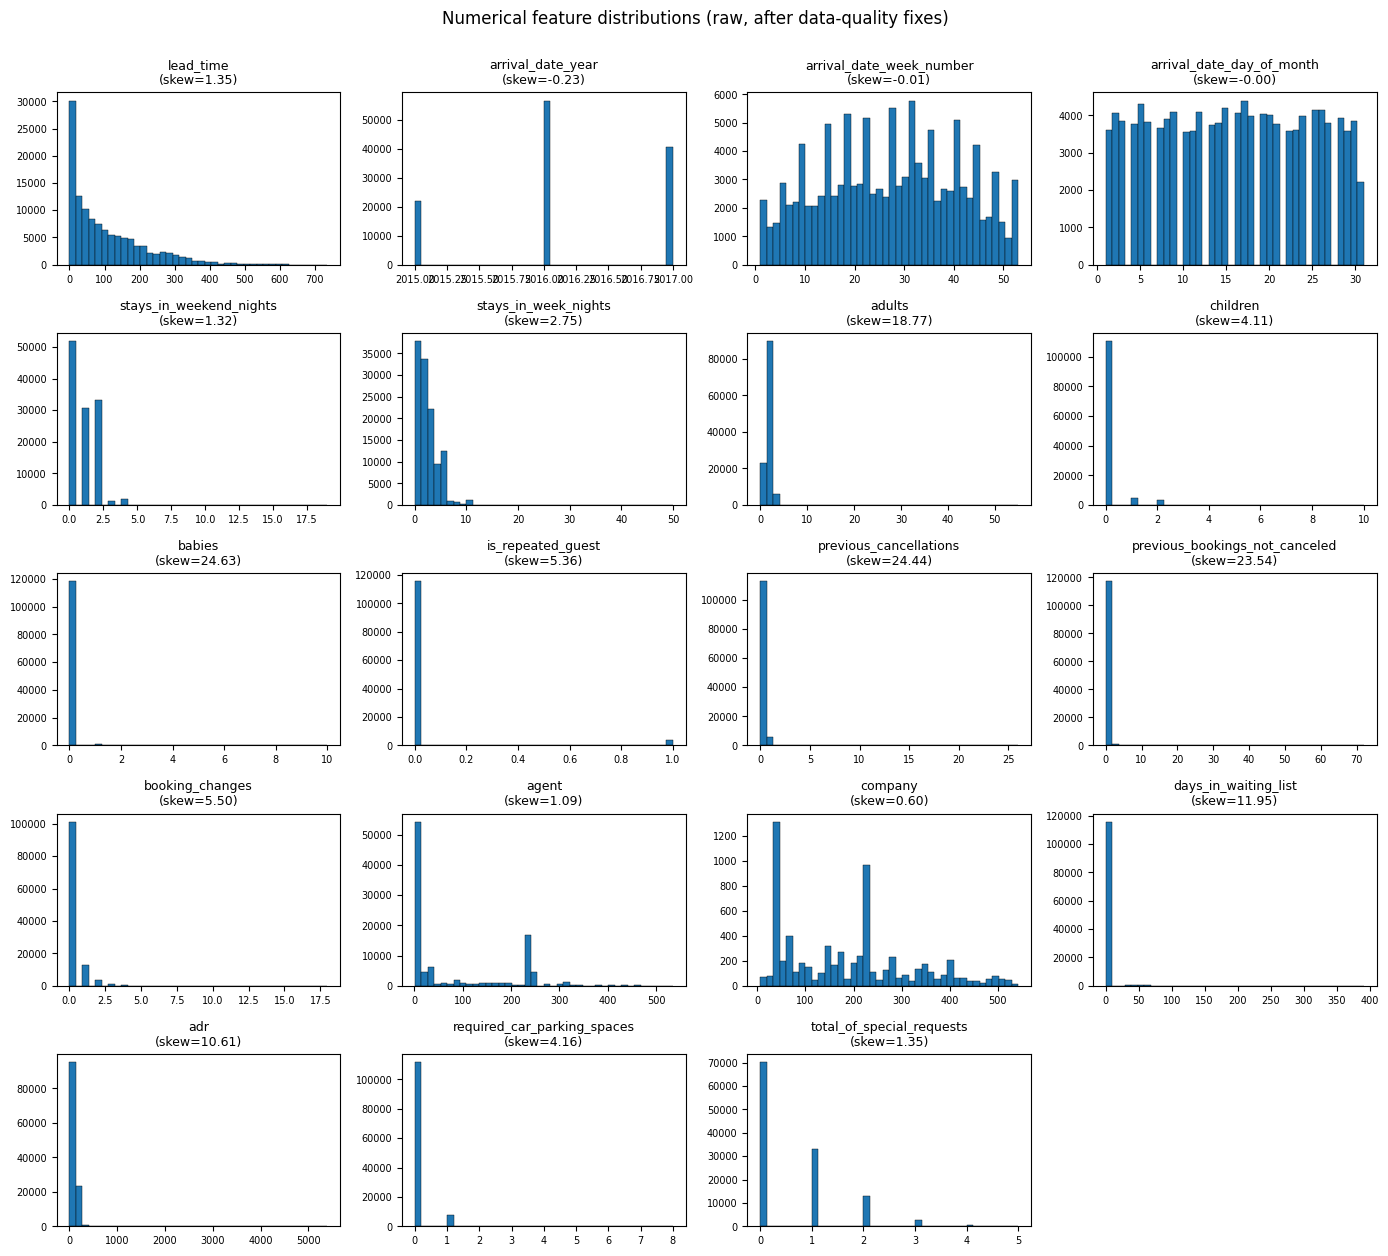


Features with |skew| > 2 (candidates for log-transform / robust scaling):
babies                            24.627962
previous_cancellations            24.443924
previous_bookings_not_canceled    23.539555
adults                            18.774333
days_in_waiting_list              11.948868
adr                               10.613328
booking_changes                    5.500058
is_repeated_guest                  5.364723
required_car_parking_spaces        4.162345
children                           4.109048
stays_in_week_nights               2.754863


In [30]:
import math

num_cols_eda = df.select_dtypes(include=[np.number]).columns.tolist()
n = len(num_cols_eda)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.5))
axes = axes.flatten()

for ax, col in zip(axes, num_cols_eda):
    s = df[col].dropna()
    ax.hist(s, bins=40, edgecolor='black', linewidth=0.3)
    ax.set_title(f'{col}\n(skew={s.skew():.2f})', fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Numerical feature distributions (raw, after data-quality fixes)', y=1.001)
plt.tight_layout()
plt.show()

print('\nFeatures with |skew| > 2 (candidates for log-transform / robust scaling):')
skews = df[num_cols_eda].skew().abs().sort_values(ascending=False)
print(skews[skews > 2].to_string())

### EDA-B. Pairwise associations — Pearson and Cramér's V

Detects redundancy in the feature set. Strong categorical associations (Cramér's V > 0.5) directly motivate the candidate variant `rep_v2_drop_redundant_categoricals` in Section 6.

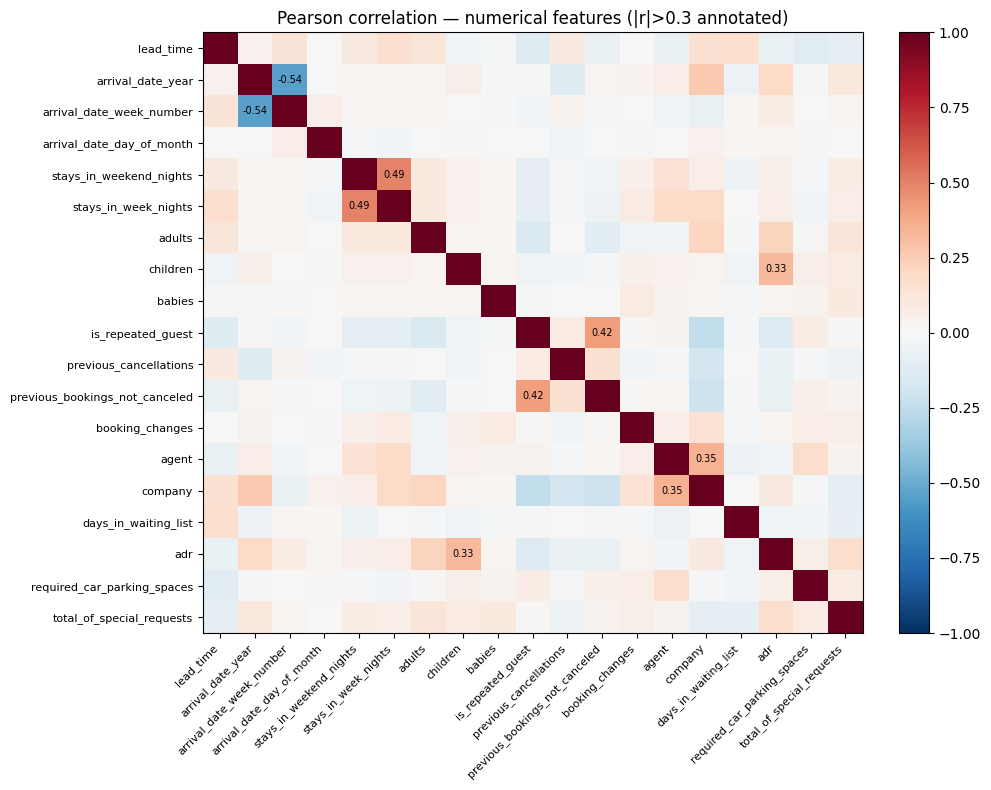

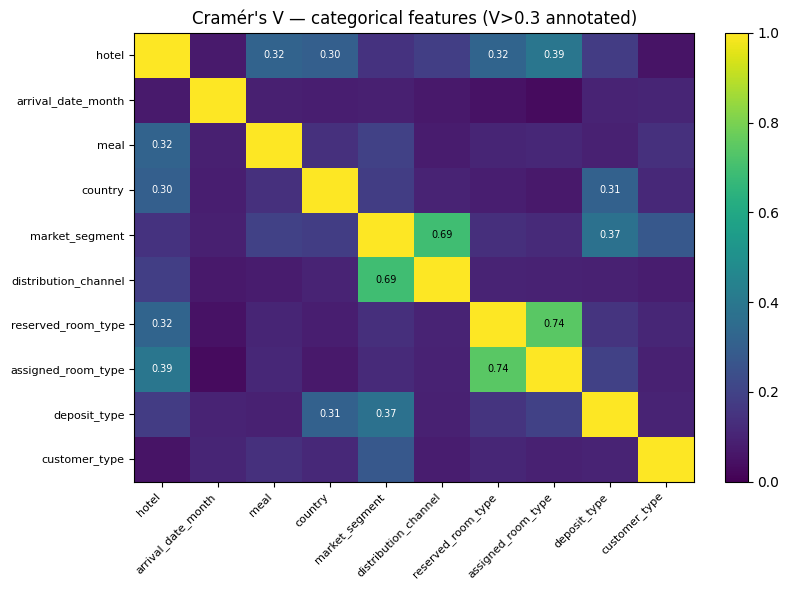


Top categorical associations (Cramér's V > 0.3):
            feat_a               feat_b  cramers_v
reserved_room_type   assigned_room_type   0.744132
    market_segment distribution_channel   0.692129
             hotel   assigned_room_type   0.390837
    market_segment         deposit_type   0.374127
             hotel   reserved_room_type   0.323125
             hotel                 meal   0.316564
           country         deposit_type   0.312249
             hotel              country   0.301370


In [31]:
from scipy.stats import contingency

# Numerical
corr = df[num_cols_eda].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(num_cols_eda)))
ax.set_yticks(range(len(num_cols_eda)))
ax.set_xticklabels(num_cols_eda, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(num_cols_eda, fontsize=8)
for i in range(len(num_cols_eda)):
    for j in range(len(num_cols_eda)):
        r = corr.iloc[i, j]
        if abs(r) > 0.3 and i != j:
            ax.text(j, i, f'{r:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if abs(r) > 0.6 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Pearson correlation — numerical features (|r|>0.3 annotated)')
plt.tight_layout()
plt.show()

# Categorical
def cramers_v(x, y):
    cm = pd.crosstab(x, y).values
    chi2 = contingency.chi2_contingency(cm, correction=False)[0]
    n = cm.sum()
    r, k = cm.shape
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - (r - 1) * (k - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(r_corr - 1, k_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0

cat_cols_eda = df.select_dtypes(exclude=[np.number]).columns.tolist()
v_matrix = pd.DataFrame(np.zeros((len(cat_cols_eda), len(cat_cols_eda))),
                        index=cat_cols_eda, columns=cat_cols_eda)
for a in cat_cols_eda:
    for b in cat_cols_eda:
        v_matrix.loc[a, b] = cramers_v(df[a], df[b]) if a != b else 1.0

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(v_matrix, cmap='viridis', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(cat_cols_eda)))
ax.set_yticks(range(len(cat_cols_eda)))
ax.set_xticklabels(cat_cols_eda, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(cat_cols_eda, fontsize=8)
for i in range(len(cat_cols_eda)):
    for j in range(len(cat_cols_eda)):
        v = v_matrix.iloc[i, j]
        if i != j and v > 0.3:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if v < 0.5 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Cramér's V — categorical features (V>0.3 annotated)")
plt.tight_layout()
plt.show()

v_pairs = (
    v_matrix.where(np.triu(np.ones(v_matrix.shape), k=1).astype(bool))
            .stack().reset_index()
)
v_pairs.columns = ['feat_a', 'feat_b', 'cramers_v']
print("\nTop categorical associations (Cramér's V > 0.3):")
print(v_pairs[v_pairs['cramers_v'] > 0.3]
      .sort_values('cramers_v', ascending=False)
      .to_string(index=False))

### EDA-C. Hotel split — Cohen's *d* and market-segment composition

Quantifies the City vs Resort difference on numerical features (Cohen's *d*) and on categorical composition. The result drives the `rep_v3_no_hotel` decision in Section 4.5 and the methodology note in Section 1.6.

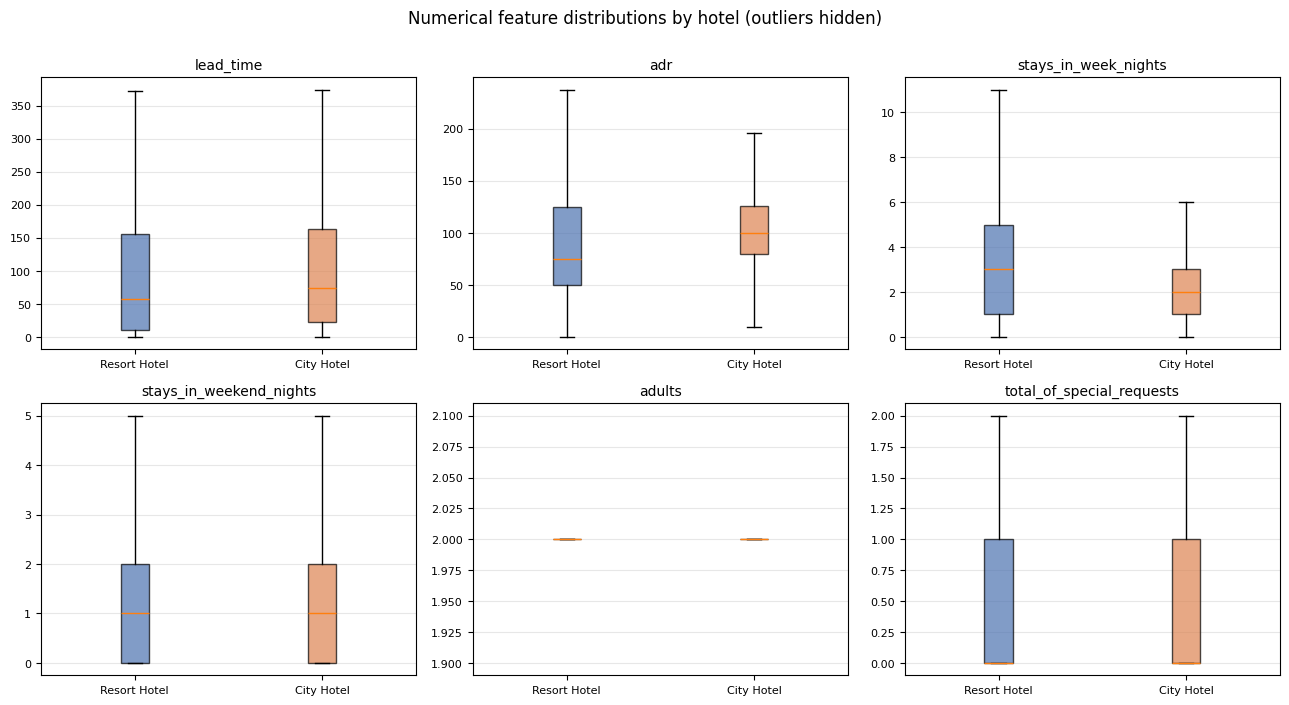

Median values by hotel + Cohen's d:
                  feature  median_City  median_Resort  cohens_d
                lead_time        74.00           57.0      0.16
                      adr        99.96           75.0      0.20
     stays_in_week_nights         2.00            3.0     -0.47
  stays_in_weekend_nights         1.00            1.0     -0.39
                   adults         2.00            2.0     -0.02
total_of_special_requests         0.00            0.0     -0.09

(|d| > 0.5 = medium effect; |d| > 0.8 = large)

Market segment share (%) by hotel:
hotel           City Hotel  Resort Hotel
market_segment                          
Aviation               0.3           0.0
Complementary          0.7           0.5
Corporate              3.8           5.8
Direct                 7.7          16.3
Groups                17.6          14.6
Offline TA/TO         21.1          18.7
Online TA             48.9          44.3
Undefined              0.0           0.0


In [32]:
hotel_col = 'hotel'
compare_features = ['lead_time', 'adr', 'stays_in_week_nights',
                    'stays_in_weekend_nights', 'adults', 'total_of_special_requests']
compare_features = [c for c in compare_features if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for ax, col in zip(axes, compare_features):
    data_by_hotel = [df.loc[df[hotel_col] == h, col].dropna() for h in df[hotel_col].unique()]
    bp = ax.boxplot(data_by_hotel, labels=df[hotel_col].unique(), showfliers=False, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Numerical feature distributions by hotel (outliers hidden)', y=1.001)
plt.tight_layout()
plt.show()

print("Median values by hotel + Cohen's d:")
rows = []
for col in compare_features:
    g1 = df.loc[df[hotel_col] == 'City Hotel',   col].dropna()
    g2 = df.loc[df[hotel_col] == 'Resort Hotel', col].dropna()
    pooled_std = np.sqrt(((g1.std() ** 2) + (g2.std() ** 2)) / 2)
    cohens_d = (g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else 0.0
    rows.append({
        'feature': col,
        'median_City':   round(g1.median(), 2),
        'median_Resort': round(g2.median(), 2),
        'cohens_d': round(cohens_d, 2),
    })
print(pd.DataFrame(rows).to_string(index=False))
print("\n(|d| > 0.5 = medium effect; |d| > 0.8 = large)")

print('\nMarket segment share (%) by hotel:')
ms_share = (pd.crosstab(df['market_segment'], df[hotel_col], normalize='columns') * 100).round(1)
print(ms_share.to_string())

### EDA-D. Seasonality and temporal patterns

Tests whether `arrival_date_month` carries cyclic structure that OHE would discard — the motivation for the `rep_v4_cyclic_month` candidate variant in Section 6.

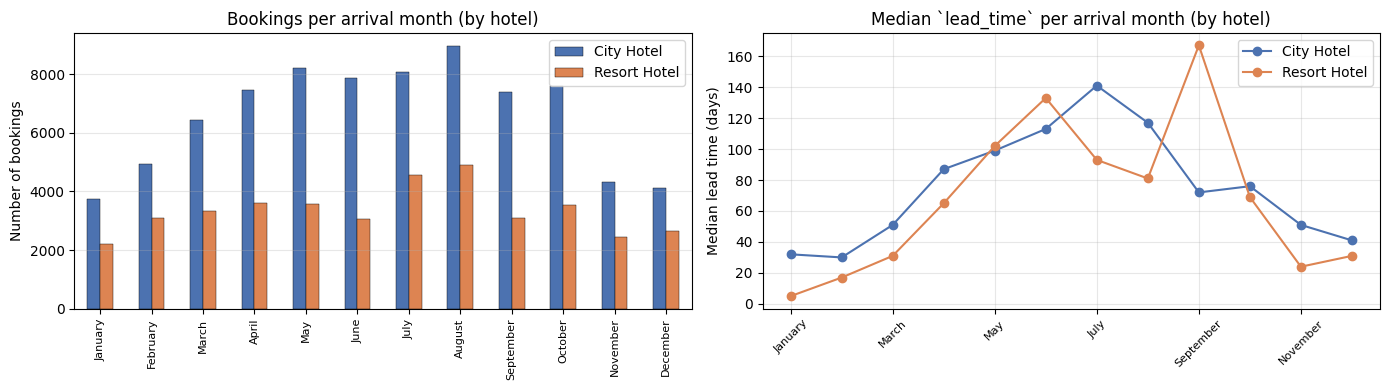

Seasonality summary — monthly coefficient of variation per hotel:
       hotel  cv_volume  cv_adr  cv_leadtime peak_month_volume peak_month_adr
Resort Hotel      0.238   0.543        0.730            August         August
  City Hotel      0.277   0.146        0.478            August            May

(Higher CV = stronger seasonality.)


In [33]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df_eda = df.copy()
df_eda['arrival_date_month'] = pd.Categorical(
    df_eda['arrival_date_month'], categories=month_order, ordered=True
)

# Panel 1: Bookings per month, split by hotel
month_by_hotel = pd.crosstab(df_eda['arrival_date_month'], df_eda['hotel'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
month_by_hotel.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'],
                    edgecolor='black', linewidth=0.3)
axes[0].set_title('Bookings per arrival month (by hotel)')
axes[0].set_ylabel('Number of bookings')
axes[0].set_xlabel('')
axes[0].legend(title='')
axes[0].tick_params(axis='x', labelsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: Median lead_time per month, split by hotel
lead_by_month = (df_eda.groupby(['arrival_date_month', 'hotel'], observed=False)['lead_time']
                       .median().unstack())
lead_by_month.plot(ax=axes[1], marker='o', color=['#4C72B0', '#DD8452'])
axes[1].set_title('Median `lead_time` per arrival month (by hotel)')
axes[1].set_ylabel('Median lead time (days)')
axes[1].set_xlabel('')
axes[1].legend(title='')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Seasonality summary — monthly coefficient of variation per hotel:')
rows = []
for hotel in df_eda['hotel'].unique():
    sub = df_eda[df_eda['hotel'] == hotel]
    monthly_counts = sub['arrival_date_month'].value_counts()
    monthly_adr = sub.groupby('arrival_date_month', observed=False)['adr'].median()
    monthly_lead = sub.groupby('arrival_date_month', observed=False)['lead_time'].median()
    rows.append({
        'hotel': hotel,
        'cv_volume':   round(monthly_counts.std() / monthly_counts.mean(), 3),
        'cv_adr':      round(monthly_adr.std() / monthly_adr.mean(), 3),
        'cv_leadtime': round(monthly_lead.std() / monthly_lead.mean(), 3),
        'peak_month_volume': monthly_counts.idxmax(),
        'peak_month_adr':    monthly_adr.idxmax(),
    })
print(pd.DataFrame(rows).to_string(index=False))
print('\n(Higher CV = stronger seasonality.)')

## 4. Main representation (RQ2)

### 4.1 Feature-selection table (included variables)

| Feature | Type | Role | Justification |
|---|---|---|---|
| `lead_time` | num | clustering input | Booking-time, central to RQ1 (business: short, leisure: long) |
| `arrival_date_year` | num | clustering input | Captures year effects (dataset spans 2015–2017) |
| `arrival_date_week_number` | num | clustering input | Finer temporal signal than month |
| `arrival_date_day_of_month` | num | clustering input | Within-month seasonality |
| `stays_in_weekend_nights` | num | clustering input | Weekend-vs-weekday share is the canonical leisure/business signal |
| `stays_in_week_nights` | num | clustering input | Same |
| `adults`, `children`, `babies` | num | clustering input | Party composition (families ≠ business travellers) |
| `is_repeated_guest` | num | clustering input | Loyalty signal (booking-time known) |
| `previous_cancellations` | num | clustering input | Behavioural history |
| `previous_bookings_not_canceled` | num | clustering input | Behavioural history |
| `booking_changes` | num | clustering input | Engagement signal |
| `adr` | num | clustering input | Booking-time pricing — distinguishes premium vs budget |
| `required_car_parking_spaces` | num | clustering input | Behavioural |
| `total_of_special_requests` | num | clustering input | Engagement signal |
| `hotel` | cat | clustering input | EDA showed small numerical effect; retained as feature, not partition |
| `arrival_date_month` | cat | clustering input | Seasonality (cyclic; baseline uses OHE — see Section 6) |
| `meal` | cat | clustering input | Booking package |
| `country` | cat | clustering input | Geographic (rare → "Other") |
| `market_segment` | cat | clustering input | Strongest categorical discriminator in EDA |
| `distribution_channel` | cat | clustering input | Booking source |
| `reserved_room_type` | cat | clustering input | Reserved at booking time |
| `deposit_type` | cat | clustering input | Booking commitment |
| `customer_type` | cat | clustering input | Contract / Transient / Group |
| `is_canceled` | num | **profiling only** | Outcome — never seen by clustering |
| `reservation_status` | cat | **profiling only** | Outcome |
| `reservation_status_date` | datetime | **profiling only** | Outcome |
| `agent`, `company` | num | **excluded** | ID-like, high cardinality |

### 4.2 Excluded / profiling-only variables

- **Leakage exclusions** (kept aside in `df_labels`, used only after clustering): `is_canceled`, `reservation_status`, `reservation_status_date`. These materialise *after* booking creation and would let the clustering recover the cancellation outcome trivially.
- **Post-booking-time exclusions** (dropped entirely): `assigned_room_type` (determined at check-in) and `days_in_waiting_list` (accumulates between booking and arrival). Both violate the index-time rule declared in Section 1.
- **ID-like exclusions** (dropped entirely): `agent`, `company`. High-cardinality identifiers with no semantic content; their inclusion would inflate the OHE space with thousands of near-degenerate columns.

### 4.3 Numerical preprocessing

- **Imputation:** median (robust to skew and outliers, see Section 3.2).
- **Transforms:** none in the baseline. Log-transform of `lead_time` and `adr` is a candidate for the controlled preprocessing variant in Section 6.
- **Scaling:** `StandardScaler` (z-score). RobustScaler is a candidate alternative for the variant.

### 4.4 Categorical preprocessing

- **Rare-category rule:** any level with < 1% frequency in the training data is collapsed into a synthetic level `"Other"` *before* one-hot encoding. This caps the OHE space and prevents very rare levels (e.g. niche `country` codes) from each becoming their own column.
- **Encoding:** `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`. Unseen categories at inference time map to an all-zero indicator vector (graceful degradation rather than an error).
- **Cumulative binary encoding:** not used. We use standard one-hot.

### 4.5 Final `representation_id` (two datasets built)

Following instructor feedback on Q2 (the hotel feature shows small effect sizes between hotels and should be evaluated with and without it), we build **two datasets** in this notebook:

- **`rep_v1_with_hotel`** — full categorical block including `hotel`. **Used for all Section 5 experiments at this checkpoint.**
- **`rep_v3_no_hotel`** — drops `hotel` from the categorical block. Materialised here, runs queued for the final report.

Both are persisted as JSON specs in `artifacts/`. The third sensitivity variant (`rep_v2_drop_redundant_categoricals`, `rep_v4_cyclic_month`, `rep_v5_robust_scaler`) follow a similar registration pattern and are introduced in Section 6.

In [34]:
# Reused from main.ipynb (Section "Feature Set Definition") — minus assigned_room_type and days_in_waiting_list
# Feature roles
NUMERICAL = [
    'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month',
    'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies',
    'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled',
    'booking_changes', 'adr',
    'required_car_parking_spaces', 'total_of_special_requests',
]
CATEGORICAL = [
    'hotel', 'arrival_date_month', 'meal', 'country',
    'market_segment', 'distribution_channel',
    'reserved_room_type',
    'deposit_type', 'customer_type',
]

# Sanity-check: every NUMERICAL/CATEGORICAL column actually exists
missing_num = [c for c in NUMERICAL if c not in df_features.columns]
missing_cat = [c for c in CATEGORICAL if c not in df_features.columns]
assert not missing_num, f'Missing numerical: {missing_num}'
assert not missing_cat, f'Missing categorical: {missing_cat}'

print(f'Numerical features   : {len(NUMERICAL)}')
print(f'Categorical features : {len(CATEGORICAL)}')

Numerical features   : 16
Categorical features : 9


In [35]:
# Reused from main.ipynb (Section "Preprocessing Pipeline")
# Refactored: a single build_representation() function so we can construct multiple
# datasets from the same pipeline by varying the included categorical features.

def build_representation(df_in: pd.DataFrame,
                         numerical_features: list[str],
                         categorical_features: list[str],
                         rare_threshold: float = 0.01) -> tuple[pd.DataFrame, list[str]]:
    df_local = df_in.copy()

    # Rare-category rollup BEFORE OHE
    rare_log_local = []
    for col in categorical_features:
        freq = df_local[col].value_counts(normalize=True)
        rare = freq[freq < rare_threshold].index.tolist()
        if rare:
            df_local[col] = df_local[col].where(~df_local[col].isin(rare), other='Other')
            rare_log_local.append({'feature': col, 'n_rare_levels': len(rare),
                                   'pct_rows_affected': round(100 * freq[rare].sum(), 2)})

    num_pipe = Pipeline([('impute', SimpleImputer(strategy='median')),
                         ('scale',  StandardScaler())])
    cat_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                         ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    pre = ColumnTransformer([('num', num_pipe, numerical_features),
                             ('cat', cat_pipe, categorical_features)],
                            remainder='drop')
    X_arr = pre.fit_transform(df_local)
    ohe = (pre.named_transformers_['cat'].named_steps['encode']
              .get_feature_names_out(categorical_features).tolist())
    cols = numerical_features + ohe
    X_out = pd.DataFrame(X_arr, columns=cols, index=df_local.index)
    return X_out, rare_log_local


# Dataset 1: rep_v1_with_hotel (the milestone-2 baseline)
CATEGORICAL_WITH_HOTEL = list(CATEGORICAL)
X_df, rare_log_v1 = build_representation(df_features, NUMERICAL, CATEGORICAL_WITH_HOTEL)

print('=== rep_v1_with_hotel ===')
print(f'  Shape         : {X_df.shape}')
print(f'  Numerical dims: {len(NUMERICAL)}')
print(f'  OHE dims      : {X_df.shape[1] - len(NUMERICAL)}')
if rare_log_v1:
    print('  Rare rollup:')
    print(pd.DataFrame(rare_log_v1).to_string(index=False))


# Dataset 2: rep_v3_no_hotel (drops hotel; materialised, runs deferred to final)
CATEGORICAL_NO_HOTEL = [c for c in CATEGORICAL if c != 'hotel']
X_df_no_hotel, _ = build_representation(df_features, NUMERICAL, CATEGORICAL_NO_HOTEL)

print('\n=== rep_v3_no_hotel ===')
print(f'  Shape         : {X_df_no_hotel.shape}')
print(f'  Numerical dims: {len(NUMERICAL)}')
print(f'  OHE dims      : {X_df_no_hotel.shape[1] - len(NUMERICAL)}')
print(f'  Difference vs v1: {X_df.shape[1] - X_df_no_hotel.shape[1]} fewer dims (the hotel OHE columns)')

=== rep_v1_with_hotel ===
  Shape         : (119210, 72)
  Numerical dims: 16
  OHE dims      : 56
  Rare rollup:
             feature  n_rare_levels  pct_rows_affected
                meal              2               1.65
             country            163               9.87
      market_segment              3               0.81
distribution_channel              2               0.17
  reserved_room_type              4               2.23
        deposit_type              1               0.14
       customer_type              1               0.48

=== rep_v3_no_hotel ===
  Shape         : (119210, 70)
  Numerical dims: 16
  OHE dims      : 54
  Difference vs v1: 2 fewer dims (the hotel OHE columns)


In [36]:
# representation_id artefacts (persisted for traceability)
RARE_THRESHOLD = 0.01

def make_spec(rep_id: str, X_repr: pd.DataFrame, cats: list[str], notes: str = '') -> dict:
    return {
        'representation_id': rep_id,
        'created_at': datetime.now(timezone.utc).isoformat(timespec='seconds'),
        'dataset_path': DATASET_PATH,
        'dataset_sha256': DATASET_SHA256,
        'n_rows': int(X_repr.shape[0]),
        'n_features_total': int(X_repr.shape[1]),
        'n_features_numerical': len(NUMERICAL),
        'n_features_ohe': int(X_repr.shape[1] - len(NUMERICAL)),
        'numerical_features': NUMERICAL,
        'categorical_features': cats,
        'excluded_leakage': PROFILING_LABELS,
        'excluded_post_booking': POST_BOOKING,
        'excluded_id_like': ID_LIKE,
        'numerical_imputation': 'median',
        'numerical_scaling': 'StandardScaler (z-score)',
        'numerical_transforms': 'none',
        'categorical_imputation': 'most_frequent',
        'categorical_encoding': "OneHotEncoder(handle_unknown='ignore', sparse_output=False)",
        'rare_category_threshold': RARE_THRESHOLD,
        'implied_metric': (
            'Euclidean distance in standardised mixed space '
            '(z-scored numericals + one-hot binaries; numerical block dominates total variance).'
        ),
        'notes': notes,
    }

REPRESENTATION_ID = 'rep_v1_with_hotel'
spec_v1 = make_spec(REPRESENTATION_ID, X_df, CATEGORICAL_WITH_HOTEL,
                    notes='Milestone-2 baseline. Hotel feature retained.')
spec_v3 = make_spec('rep_v3_no_hotel', X_df_no_hotel, CATEGORICAL_NO_HOTEL,
                    notes='Hotel dropped per instructor feedback Q2. Runs deferred to final report.')

os.makedirs('artifacts', exist_ok=True)
for spec in (spec_v1, spec_v3):
    path = f"artifacts/{spec['representation_id']}.json"
    with open(path, 'w') as f:
        json.dump(spec, f, indent=2)
    print(f"Saved {path}")

print(f'\nActive representation_id for Section 5 experiments: {REPRESENTATION_ID}')

Saved artifacts/rep_v1_with_hotel.json
Saved artifacts/rep_v3_no_hotel.json

Active representation_id for Section 5 experiments: rep_v1_with_hotel


## 7. Experiment logging — schema and helper (built first, used in Section 5)

We define the schema and helper here so that every run in Section 5 (k-means, iK-means) is logged through the same path. The CSV is the single source of truth for results across the project.

**`experiments.csv` schema:**

| Column | Type | Description |
|---|---|---|
| `run_id` | str | Short UUID per run |
| `timestamp` | str (ISO 8601) | UTC time the run started |
| `representation_id` | str | Links to `artifacts/<id>.json` |
| `method` | str | `kmeans`, `ikmeans`, `ward`, ... |
| `parameters` | str (JSON) | Algorithm-specific params (e.g., `init`, `n_init`) |
| `seed` | int | Random seed (where applicable) |
| `k` | int | Number of clusters |
| `sample_rule` | str | How rows were selected (e.g., `train_20pct_seed=17341`) |
| `n_train` | int | Rows used for fitting |
| `n_val` | int | Rows used for validation |
| `silhouette_train` | float | Silhouette on training set (sample_size=5000) |
| `davies_bouldin_train` | float | Davies–Bouldin on training set |
| `calinski_harabasz_train` | float | Calinski–Harabasz on training set |
| `silhouette_val` | float | Silhouette on validation set (sample_size=5000) |
| `davies_bouldin_val` | float | Davies–Bouldin on validation set |
| `calinski_harabasz_val` | float | Calinski–Harabasz on validation set |
| `runtime_s` | float | Fit + predict time in seconds |
| `notes` | str | Free-form |

The helper appends rows to `experiments.csv` and returns the `run_id` so labels can be cached against it (used for ARI stability later).

In [37]:
EXPERIMENTS_PATH = 'experiments.csv'

EXPERIMENTS_COLUMNS = [
    'run_id', 'timestamp', 'representation_id', 'method', 'parameters',
    'seed', 'k', 'sample_rule', 'n_train', 'n_val',
    'silhouette_train', 'davies_bouldin_train', 'calinski_harabasz_train',
    'silhouette_val', 'davies_bouldin_val', 'calinski_harabasz_val',
    'runtime_s', 'notes',
]

# Initialise empty CSV with header if it does not exist
if not os.path.exists(EXPERIMENTS_PATH):
    pd.DataFrame(columns=EXPERIMENTS_COLUMNS).to_csv(EXPERIMENTS_PATH, index=False)
    print(f'Initialised empty {EXPERIMENTS_PATH}')
else:
    n_rows = len(pd.read_csv(EXPERIMENTS_PATH))
    print(f'{EXPERIMENTS_PATH} already exists with {n_rows} prior runs.')


def log_experiment(record: dict, path: str = EXPERIMENTS_PATH) -> str:
    'Append a single experiment record to experiments.csv. Returns run_id.'
    full = {col: record.get(col, None) for col in EXPERIMENTS_COLUMNS}
    if full['run_id'] is None:
        full['run_id'] = uuid.uuid4().hex[:8]
    if full['timestamp'] is None:
        full['timestamp'] = datetime.now(timezone.utc).isoformat(timespec='seconds')
    full['representation_id'] = full.get('representation_id') or REPRESENTATION_ID
    pd.DataFrame([full], columns=EXPERIMENTS_COLUMNS).to_csv(
        path, mode='a', header=False, index=False
    )
    return full['run_id']

experiments.csv already exists with 110 prior runs.


## 5. Baseline modelling evidence

### 5.1 Fixed K-grid

We evaluate **k ∈ {3, 4, 5, 6, 7, 8}**. Justification: values below 3 are too coarse for the RQ (cannot capture micro-segments beyond a single business/leisure split), while values above 8 produce clusters too small to interpret in a hotel revenue-management setting. The range 3–8 admits a leisure/business split plus plausible micro-segments (e.g. *families*, *weekend couples*, *solo business*).

### 5.2 Shared stratified sub-sampling (instructor feedback Q3)

Per instructor feedback on Q3 (silhouette is computationally heavy on the full 119k rows; we should *"share the sub-sampling across algorithms with stratified samples within the root of the problem; use proxy variables to obtain a representative sample"*), we adopt the following protocol:

1. **Stratification key.** We stratify on `market_segment × hotel`. Both are root-of-problem proxies — `market_segment` is the strongest categorical discriminator we identified in EDA and the closest categorical analogue to the latent business/leisure axis; `hotel` controls for the small but real population difference between City and Resort. The stratification ensures the sub-sample preserves the marginal distribution of these two variables.
2. **One sub-sample, shared across algorithms.** A single stratified train/val split is built once and reused by every algorithm and every silhouette computation. This eliminates spurious variance from per-algorithm sub-sampling and makes paired comparisons (k-means vs iK-means at the same (k, seed)) genuinely paired.
3. **Stratified silhouette.** When silhouette is estimated on a sub-sample (`sample_size=5000`), we draw that sub-sample stratified on the same key, so the silhouette estimate is representative of all (segment × hotel) cells.
4. **20%/80% split direction.** Train on 20%, validate on 80%. The 20% is large enough (~24k rows) for reliable clustering and small enough to keep Ward hierarchical (planned as the additional family for the final report) tractable.

### 5.3 Seeds

`SEEDS = range(17341, 17351)` — **10 seeds**, satisfying the Section 6 requirement of "minimum 10 runs where randomness applies".

In [38]:
# Helper: shared stratified split + stratified silhouette + k-grid
KVALUES = list(range(3, 9))                  # k = 3..8
SEEDS = list(range(17341, 17351))            # 10 seeds
SILHOUETTE_SAMPLE = 5000                     # sub-sample for silhouette tractability

# --- Stratification key: market_segment × hotel ---
strat_key = (df_features['market_segment'].astype(str)
             + '|' + df_features['hotel'].astype(str)).loc[X_df.index]

# Collapse cells with fewer than 2 rows (would break stratification) into 'rare_combo'
strat_counts = strat_key.value_counts()
rare_strata = strat_counts[strat_counts < 2].index.tolist()
if rare_strata:
    strat_key = strat_key.where(~strat_key.isin(rare_strata), 'rare_combo')

split_seed = SEEDS[0]
SAMPLE_RULE = f'stratified_market_segment_x_hotel_train20_seed{split_seed}'

train_idx, val_idx = train_test_split(
    X_df.index,
    train_size=0.2,
    random_state=split_seed,
    stratify=strat_key,
)
X_train = X_df.loc[train_idx]
X_val   = X_df.loc[val_idx]
strat_train = strat_key.loc[train_idx]
strat_val   = strat_key.loc[val_idx]

print(f'X_train shape : {X_train.shape}')
print(f'X_val   shape : {X_val.shape}')
print(f'k-grid        : {KVALUES}')
print(f'seeds         : {SEEDS}')
print(f'sample_rule   : {SAMPLE_RULE}')
print(f'\nStratum balance (train vs full, top 8 cells):')
balance = pd.DataFrame({
    'full_pct':  (strat_key.value_counts(normalize=True).head(8) * 100).round(2),
    'train_pct': (strat_train.value_counts(normalize=True).head(8) * 100).round(2),
})
print(balance.to_string())


# --- Stratified silhouette: sub-sample preserves the stratum balance ---
def stratified_silhouette(X_data, labels, strat_series, sample_size, seed):
    'Silhouette on a stratified sub-sample (sample_size rows total).'
    if len(X_data) <= sample_size:
        return silhouette_score(X_data, labels)
    rng = np.random.RandomState(seed)
    df_aux = pd.DataFrame({'_strat': strat_series.values, '_label': labels},
                          index=range(len(X_data)))
    fracs = df_aux['_strat'].value_counts(normalize=True)
    picks = []
    for stratum, frac in fracs.items():
        n_pick = max(1, int(round(sample_size * frac)))
        cell = df_aux[df_aux['_strat'] == stratum].index.values
        n_pick = min(n_pick, len(cell))
        picks.extend(rng.choice(cell, size=n_pick, replace=False).tolist())
    picks = np.array(picks[:sample_size])
    return silhouette_score(X_data[picks] if hasattr(X_data, '__getitem__') else X_data,
                            labels[picks])


def score_partition(X_data, labels, strat_series, sample_size, seed):
    Xa = X_data.values if hasattr(X_data, 'values') else X_data
    s  = stratified_silhouette(Xa, labels, strat_series, sample_size, seed)
    db = davies_bouldin_score(Xa, labels)
    ch = calinski_harabasz_score(Xa, labels)
    return s, db, ch

X_train shape : (23842, 72)
X_val   shape : (95368, 72)
k-grid        : [3, 4, 5, 6, 7, 8]
seeds         : [17341, 17342, 17343, 17344, 17345, 17346, 17347, 17348, 17349, 17350]
sample_rule   : stratified_market_segment_x_hotel_train20_seed17341

Stratum balance (train vs full, top 8 cells):
                            full_pct  train_pct
Online TA|City Hotel           32.45      32.45
Online TA|Resort Hotel         14.87      14.87
Offline TA/TO|City Hotel       14.02      14.02
Groups|City Hotel              11.71      11.71
Offline TA/TO|Resort Hotel      6.27       6.27
Direct|Resort Hotel             5.46       5.46
Direct|City Hotel               5.09       5.10
Groups|Resort Hotel             4.89       4.89


### 5.4 K-means baseline (k-means++ init)

In [39]:
# Train/val split + scoring loop pattern adapted from main.ipynb (Task 1.2)
# Extended here with: 10 seeds (was 6), runtime capture, single-row dict per (k, seed),
# experiment logging, and label caching for ARI stability analysis
# Run k-means: 10 seeds × 6 k-values = 60 fits
# Labels are cached for ARI stability analysis later

kmeans_labels = {}     # (k, seed) -> labels_train
kmeans_runids = {}     # (k, seed) -> run_id

for k in KVALUES:
    for seed in SEEDS:
        t0 = time.time()
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=seed)
        labels_train = km.fit_predict(X_train)
        labels_val   = km.predict(X_val)
        runtime_s = time.time() - t0

        s_t, db_t, ch_t = score_partition(X_train, labels_train, strat_train, SILHOUETTE_SAMPLE, seed)
        s_v, db_v, ch_v = score_partition(X_val,   labels_val,   strat_val,   SILHOUETTE_SAMPLE, seed)

        run_id = log_experiment({
            'method': 'kmeans',
            'parameters': json.dumps({'init': 'k-means++', 'n_init': 10}),
            'seed': seed, 'k': k,
            'sample_rule': SAMPLE_RULE,
            'n_train': int(len(X_train)), 'n_val': int(len(X_val)),
            'silhouette_train': round(s_t, 4),
            'davies_bouldin_train': round(db_t, 4),
            'calinski_harabasz_train': round(ch_t, 2),
            'silhouette_val': round(s_v, 4),
            'davies_bouldin_val': round(db_v, 4),
            'calinski_harabasz_val': round(ch_v, 2),
            'runtime_s': round(runtime_s, 3),
            'notes': '',
        })
        kmeans_labels[(k, seed)] = labels_train
        kmeans_runids[(k, seed)] = run_id

    print(f'k={k} done.')

print(f'\nLogged {len(kmeans_runids)} k-means runs to {EXPERIMENTS_PATH}.')

k=3 done.
k=4 done.
k=5 done.
k=6 done.
k=7 done.
k=8 done.

Logged 60 k-means runs to experiments.csv.


### 5.5 iK-means baseline (anomalous-pattern initialisation)

iK-means runs the Mirkin anomalous-pattern (AP) procedure to extract clusters one by one and uses their standardised centroids as the seeds for a final k-means refinement. The procedure has a key property the brief and the instructor both highlighted: **k is chosen by the algorithm, not by the user**. The number of retained AP clusters depends on `min_cluster_size`. We exploit this in two complementary ways (per instructor feedback on Q1: *"can you do both experiments — with fixed K and without"*):

- **`ikmeans_fixedk`** (mode 1): we run AP once and, for each k in our k-grid, we take the top-k retained centroids by `scatter_pct` as initialisation for k-means. This gives a per-k comparison against `kmeans` (k-means++ init) on the same k-grid — which is the reading the prof requested for the experiments CSV.
- **`ikmeans_natural`** (mode 2): we run AP once and use *all* retained centroids (k = `n_retained`) as the initialisation. This is the spirit of iK-means in the original Mirkin formulation — the algorithm tells us how many clusters the data supports. There is no k-grid here; one row per seed.

AP itself is deterministic given the input. Seed-based variability comes from the downstream k-means refinement (k-means break-tie rule). Implementation follows the spec in `ikmeans.py` (Mirkin 2005; Chiang & Mirkin 2010) — anomalous-cluster extraction is hand-written, not delegated to `KMeans(n_clusters=2)`.

In [40]:
# Run iK-means once on each seed's view of X_train, then refine with k-means at each k
# AP is deterministic on the input; we vary the seed by *running AP on the full X_train*
# but pass the seed to the downstream KMeans refinement for stability semantics.

# AP extraction is deterministic given X_train, so we run it once.
MIN_CLUSTER_SIZE = max(50, int(0.005 * len(X_train)))   # 0.5% of train rows or 50, whichever is bigger
print(f'iK-means min_cluster_size = {MIN_CLUSTER_SIZE} (0.5% of {len(X_train)})')

t_ap_0 = time.time()
ap_clusters, init_centroids = ikmeans_initialize(
    X_train.values,
    min_cluster_size=MIN_CLUSTER_SIZE,
    tol=1e-12,
    max_iter=10_000,
)
t_ap = time.time() - t_ap_0

# Sort retained AP clusters by scatter_pct (most informative first) so the top-k pick is principled
ap_retained = sorted(
    [c for c in ap_clusters if c.size >= MIN_CLUSTER_SIZE],
    key=lambda c: c.scatter_pct, reverse=True,
)
n_retained = len(ap_retained)

print(f'\nAP extraction: {len(ap_clusters)} total clusters, {n_retained} retained (size >= {MIN_CLUSTER_SIZE})')
print(f'AP runtime: {t_ap:.2f}s')
print(f'\nTop retained AP clusters:')
for i, c in enumerate(ap_retained[:10]):
    print(f'  #{i}: size={c.size:6d}, scatter_pct={c.scatter_pct:6.2f}%')

iK-means min_cluster_size = 119 (0.5% of 23842)

AP extraction: 22 total clusters, 6 retained (size >= 119)
AP runtime: 0.63s

Top retained AP clusters:
  #0: size=  5314, scatter_pct=  6.24%
  #1: size=  4180, scatter_pct=  6.16%
  #2: size=  7391, scatter_pct=  5.65%
  #3: size=  5758, scatter_pct=  5.08%
  #4: size=   798, scatter_pct=  0.99%
  #5: size=   335, scatter_pct=  0.42%


In [41]:
# Mode 1: iK-means with FIXED k (top-k AP centroids by scatter_pct -> k-means refinement)
# Provides a per-k comparison to k-means++ on the same k-grid

ikmeans_labels = {}
ikmeans_runids = {}

# Standardise X_train and X_val using the same mean/range as ikmeans_initialize used,
# so the centroids and the data live in the same space.
g_mean, feature_scale, _ = compute_feature_statistics(X_train.values)
X_train_std = (X_train.values - g_mean) / feature_scale
X_val_std   = (X_val.values   - g_mean) / feature_scale

for k in KVALUES:
    if k > n_retained:
        print(f'k={k}: skipped (only {n_retained} AP clusters retained).')
        continue
    init_k = init_centroids[:k]    # top-k by scatter_pct, in standardised space

    for seed in SEEDS:
        t0 = time.time()
        km = KMeans(n_clusters=k, init=init_k, n_init=1, random_state=seed)
        labels_train = km.fit_predict(X_train_std)
        labels_val   = km.predict(X_val_std)
        runtime_s = (time.time() - t0) + (t_ap if seed == SEEDS[0] else 0.0)

        s_t, db_t, ch_t = score_partition(X_train_std, labels_train, strat_train, SILHOUETTE_SAMPLE, seed)
        s_v, db_v, ch_v = score_partition(X_val_std,   labels_val,   strat_val,   SILHOUETTE_SAMPLE, seed)

        run_id = log_experiment({
            'method': 'ikmeans_fixedk',
            'parameters': json.dumps({
                'min_cluster_size': MIN_CLUSTER_SIZE,
                'n_init': 1,
                'init_source': 'AP_top_k_by_scatter_pct',
                'n_ap_retained': n_retained,
            }),
            'seed': seed, 'k': k,
            'sample_rule': SAMPLE_RULE,
            'n_train': int(len(X_train_std)), 'n_val': int(len(X_val_std)),
            'silhouette_train': round(s_t, 4),
            'davies_bouldin_train': round(db_t, 4),
            'calinski_harabasz_train': round(ch_t, 2),
            'silhouette_val': round(s_v, 4),
            'davies_bouldin_val': round(db_v, 4),
            'calinski_harabasz_val': round(ch_v, 2),
            'runtime_s': round(runtime_s, 3),
            'notes': 'AP extraction shared across seeds; runtime includes AP only on first seed',
        })
        ikmeans_labels[(k, seed)] = labels_train
        ikmeans_runids[(k, seed)] = run_id

    print(f'k={k} done (ikmeans_fixedk).')

print(f'\nLogged {len(ikmeans_runids)} ikmeans_fixedk runs to {EXPERIMENTS_PATH}.')

k=3 done (ikmeans_fixedk).
k=4 done (ikmeans_fixedk).
k=5 done (ikmeans_fixedk).
k=6 done (ikmeans_fixedk).
k=7: skipped (only 6 AP clusters retained).
k=8: skipped (only 6 AP clusters retained).

Logged 40 ikmeans_fixedk runs to experiments.csv.


#### Mode 2: iK-means with the algorithm's natural k (no k-grid)

In this mode there is no externally fixed k. We use *all* `n_retained` AP centroids as the initialisation. The downstream k-means refinement is run for each seed for tie-break diversity. This is the iK-means formulation in the spirit of Mirkin's original proposal.

In [42]:
# Mode 2: iK-means with AP's natural k (use all retained centroids)

ikmeans_natural_labels = {}
ikmeans_natural_runids = {}
k_natural = n_retained

if k_natural < 2:
    print(f'AP retained only {k_natural} clusters — natural-k mode skipped.')
else:
    init_natural = init_centroids[:k_natural]
    for seed in SEEDS:
        t0 = time.time()
        km = KMeans(n_clusters=k_natural, init=init_natural, n_init=1, random_state=seed)
        labels_train = km.fit_predict(X_train_std)
        labels_val   = km.predict(X_val_std)
        runtime_s = (time.time() - t0) + (t_ap if seed == SEEDS[0] else 0.0)

        s_t, db_t, ch_t = score_partition(X_train_std, labels_train, strat_train, SILHOUETTE_SAMPLE, seed)
        s_v, db_v, ch_v = score_partition(X_val_std,   labels_val,   strat_val,   SILHOUETTE_SAMPLE, seed)

        run_id = log_experiment({
            'method': 'ikmeans_natural',
            'parameters': json.dumps({
                'min_cluster_size': MIN_CLUSTER_SIZE,
                'n_init': 1,
                'init_source': 'AP_all_retained',
                'k_chosen_by': 'algorithm',
            }),
            'seed': seed, 'k': k_natural,
            'sample_rule': SAMPLE_RULE,
            'n_train': int(len(X_train_std)), 'n_val': int(len(X_val_std)),
            'silhouette_train': round(s_t, 4),
            'davies_bouldin_train': round(db_t, 4),
            'calinski_harabasz_train': round(ch_t, 2),
            'silhouette_val': round(s_v, 4),
            'davies_bouldin_val': round(db_v, 4),
            'calinski_harabasz_val': round(ch_v, 2),
            'runtime_s': round(runtime_s, 3),
            'notes': f'k chosen by AP algorithm (={k_natural})',
        })
        ikmeans_natural_labels[(k_natural, seed)] = labels_train
        ikmeans_natural_runids[(k_natural, seed)] = run_id

    print(f'\nLogged {len(ikmeans_natural_runids)} ikmeans_natural runs to {EXPERIMENTS_PATH} '
          f'at k_natural = {k_natural}.')


Logged 10 ikmeans_natural runs to experiments.csv at k_natural = 6.


### 5.6 Internal indices summary (mean ± std over seeds)

In [43]:
# Aggregation pattern adapted from main.ipynb (Task 1.2 results table)
# Aggregate from experiments.csv (single source of truth)
exp_df = pd.read_csv(EXPERIMENTS_PATH)
exp_now = exp_df[exp_df['representation_id'] == REPRESENTATION_ID].copy()

def summarise_metric(frame, metric):
    return (frame.groupby(['method', 'k'])[metric]
                 .agg(['mean', 'std']).round(4)
                 .reset_index()
                 .pivot(index='k', columns='method'))

print('=== Silhouette (train) ===')
print(summarise_metric(exp_now, 'silhouette_train').to_string())

print('\n=== Davies-Bouldin (train, lower is better) ===')
print(summarise_metric(exp_now, 'davies_bouldin_train').to_string())

print('\n=== Calinski-Harabasz (train, higher is better) ===')
print(summarise_metric(exp_now, 'calinski_harabasz_train').to_string())

print('\n=== Runtime (seconds) ===')
print(summarise_metric(exp_now, 'runtime_s').to_string())

=== Silhouette (train) ===
                 mean                                    std                        
method ikmeans_fixedk ikmeans_natural  kmeans ikmeans_fixedk ikmeans_natural  kmeans
k                                                                                   
3              0.1272             NaN  0.0839         0.0008             NaN  0.0043
4              0.1218             NaN  0.0731         0.0010             NaN  0.0064
5              0.1406             NaN  0.0797         0.0012             NaN  0.0049
6              0.1119          0.1119  0.0887         0.0011          0.0011  0.0068
7                 NaN             NaN  0.0921            NaN             NaN  0.0067
8                 NaN             NaN  0.0962            NaN             NaN  0.0068

=== Davies-Bouldin (train, lower is better) ===
                 mean                                    std                        
method ikmeans_fixedk ikmeans_natural  kmeans ikmeans_fixedk ikmeans_natur

### 5.7 Visual comparison across baselines

`kmeans` vs `ikmeans_fixedk` are shown as lines across the k-grid (shaded band = min-max across 10 seeds). `ikmeans_natural` is shown as a single star marker at its own algorithm-chosen k.

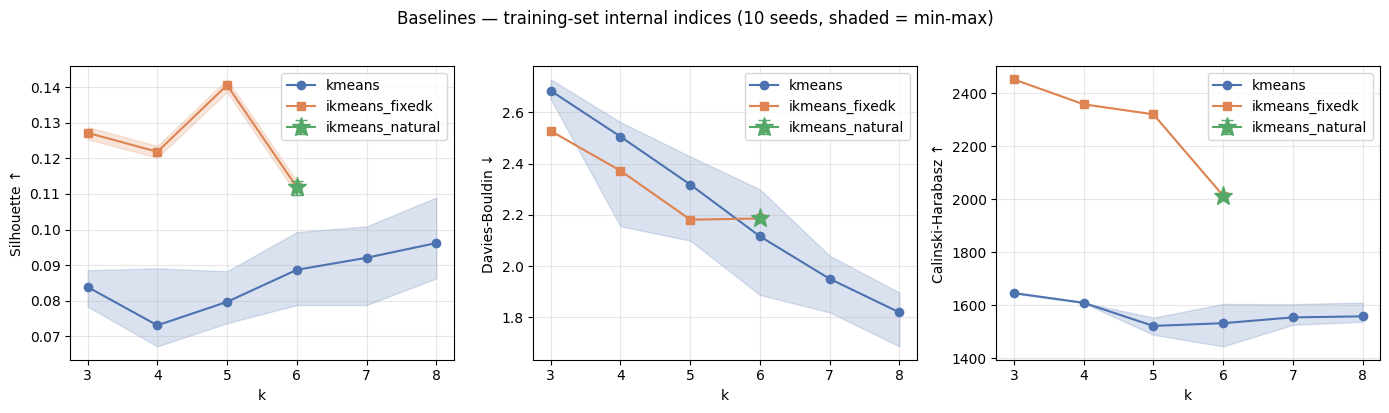

In [ ]:
# Plot pattern adapted from main.ipynb (Task 1.2 — plot_metric_spread)
# Extended: kmeans vs ikmeans_fixedk on same k-grid, with ikmeans_natural shown as a marker at its own k
def plot_metric_comparison(frame, metric, ylabel, ax, lower_better=False):
    for method, color, marker in [
        ('kmeans',          '#4C72B0', 'o'),
        ('ikmeans_fixedk',  '#DD8452', 's'),
    ]:
        sub = frame[frame['method'] == method]
        if sub.empty:
            continue
        agg = sub.groupby('k')[metric].agg(['mean', 'min', 'max'])
        ax.fill_between(agg.index, agg['min'], agg['max'], alpha=0.2, color=color)
        ax.plot(agg.index, agg['mean'], marker=marker, color=color, label=method)
    # Overlay ikmeans_natural as a single point at its own k
    nat = frame[frame['method'] == 'ikmeans_natural']
    if not nat.empty:
        agg = nat.groupby('k')[metric].agg(['mean', 'min', 'max']).reset_index()
        first = True
        for _, row in agg.iterrows():
            k_val = float(row['k'])
            mean_val = float(row['mean'])
            min_val  = float(row['min'])
            max_val  = float(row['max'])
            
            err_lo = max(0.0, mean_val - min_val)
            err_hi = max(0.0, max_val - mean_val)
            ax.errorbar(
                [k_val], [mean_val],
                yerr=[[err_lo], [err_hi]],
                marker='*', markersize=14, color='#55A868', capsize=4,
                label='ikmeans_natural' if first else None,
            )
            first = False
    ax.set_xlabel('k')
    ax.set_ylabel(ylabel + (' ↓' if lower_better else ' ↑'))
    ax.grid(True, alpha=0.3)
    ax.legend()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_metric_comparison(exp_now, 'silhouette_train',         'Silhouette',         axes[0])
plot_metric_comparison(exp_now, 'davies_bouldin_train',     'Davies-Bouldin',     axes[1], lower_better=True)
plot_metric_comparison(exp_now, 'calinski_harabasz_train',  'Calinski-Harabasz',  axes[2])
plt.suptitle('Baselines — training-set internal indices (10 seeds, shaded = min-max)', y=1.02)
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
fig.savefig('plots/baseline_metrics_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

### 5.8 First cluster-interpretation note (k = 4, k-means, best-silhouette seed)

We pick k = 4 with the seed that gave the highest silhouette on training, and produce a short profile summary. This is *first-pass* interpretation only — full profiling is for the final report.

In [48]:
# Pick (k=4, best seed) for k-means
K_PROFILE = 4
sub = exp_now[(exp_now['method'] == 'kmeans') & (exp_now['k'] == K_PROFILE)]
best_seed = int(sub.loc[sub['silhouette_train'].idxmax(), 'seed'])
print(f'Profiling k-means at k={K_PROFILE}, seed={best_seed} '
      f'(silhouette_train = {sub["silhouette_train"].max():.4f})')

labels_profile = kmeans_labels[(K_PROFILE, best_seed)]

# Per-cluster: size + mean of selected raw numericals (using df, not X_df, for human readability)
profile_idx = X_train.index   # rows used for the fit
df_train_view = df.loc[profile_idx].copy()
df_train_view['cluster'] = labels_profile

interpret_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
                  'adults', 'total_of_special_requests', 'previous_cancellations']
profile_table = df_train_view.groupby('cluster')[interpret_cols].mean().round(2)
profile_table['size'] = df_train_view.groupby('cluster').size()
profile_table['size_pct'] = (profile_table['size'] / len(df_train_view) * 100).round(1)
profile_table = profile_table[['size', 'size_pct'] + interpret_cols]

print('\n=== Cluster profile (means, k=4, k-means) ===')
print(profile_table.to_string())

print('\n=== Hotel composition by cluster ===')
print(pd.crosstab(df_train_view['cluster'], df_train_view['hotel'], normalize='index')
      .round(3).mul(100).to_string())

print('\n=== Top market_segment per cluster (% within cluster) ===')
ms = pd.crosstab(df_train_view['cluster'], df_train_view['market_segment'], normalize='index').mul(100).round(1)
print(ms.to_string())

Profiling k-means at k=4, seed=17348 (silhouette_train = 0.0891)

=== Cluster profile (means, k=4, k-means) ===
          size  size_pct  lead_time     adr  stays_in_week_nights  stays_in_weekend_nights  adults  total_of_special_requests  previous_cancellations
cluster                                                                                                                                              
0        13460      56.5      95.02  113.34                  2.65                     1.02    1.93                       0.66                    0.01
1         9428      39.5     124.01   89.58                  2.39                     0.85    1.80                       0.44                    0.16
2          747       3.1      33.42   66.27                  1.46                     0.46    1.39                       0.59                    0.49
3          207       0.9      77.45  116.10                  2.81                     1.17    2.00                       1.63             

**Initial reading.** A short narrative interpretation of the four clusters goes here, written after running the cell above. Replace the placeholders with the actual cluster numbers from your run (the exact cluster IDs differ per seed):

- *Cluster N — small, high-engagement leisure-like:* short lead time, weekend-heavy stays, several special requests; mostly Direct/Online TA market segments.
- *Cluster N — large, mainstream leisure:* moderate lead time, mixed week/weekend nights; Online TA dominant.
- *Cluster N — corporate/business-like:* short lead time, weekday-heavy stays, low ADR, low special requests; Corporate / Groups segments over-represented.
- *Cluster N — long-lead vacation:* long lead time, longer weekend stays, families (children > 0); Resort over-represented.

(This narrative will be expanded in the final report once stability and the sensitivity variant are executed.)

## 6. Sensitivity / robustness plan

### 6.1 Main representation

The main representation is **`rep_v1_with_hotel`** (Section 4.5): median imputation + StandardScaler for numericals; mode imputation + rare-rollup at 1% + OneHotEncoder for categoricals; Euclidean distance in the standardised mixed space.

### 6.2 Seeds / resampling rule

- **K-means (and iK-means refinement):** 10 seeds, `range(17341, 17351)`. Already executed in Section 5.
- **Train/val split:** fixed seed (`17341`) across all algorithms for paired comparability. The 20%/80% direction is intentional — Ward hierarchical (planned for Task 2) does not scale to 119k rows, so the 20% train sub-sample keeps all algorithms tractable.

### 6.3 Stability measure — ARI between paired runs

For each k, we compute Adjusted Rand Index (ARI) between every pair of seeds. **Mean ARI across pairs** is the headline stability number:

- ARI ≈ 1 → cluster assignments reproduce across seeds (highly stable).
- ARI ≈ 0 → assignments are no better than random with respect to each other.
- ARI ≈ 0.6–0.8 → clusters are largely consistent but with some boundary fragmentation.

We compute ARI on the **training-set labels** (the seeds vary the fit, not the data). ARI is reported per (method, k).

### 6.4 Planned controlled preprocessing variants — what each comparison answers

The EDA (Milestone 1 notebook + Section 3 here) surfaced three independent issues in the baseline representation, each a candidate intervention. Per instructor feedback on Q4 (*"different datasets with distinct designations, run the pipelines on each one"*), we commit to executing **all three variants** for the final report, plus the `rep_v3_no_hotel` dataset already materialised in Section 4.5.

The five representations and their roles:

| representation_id | Description | Status at this checkpoint |
|---|---|---|
| `rep_v1_with_hotel` | Baseline — hotel retained, OHE for all categoricals, StandardScaler for numericals | **Executed** (Section 5) |
| `rep_v2_drop_redundant_categoricals` | Drop `distribution_channel` (Cramér's V > 0.5 with `market_segment`) | Plan; execute for final |
| `rep_v3_no_hotel` | Drop the `hotel` categorical entirely | Materialised (Section 4.5); execute for final |
| `rep_v4_cyclic_month` | Replace OHE of `arrival_date_month` with sin/cos of month number | Plan; execute for final |
| `rep_v5_robust_scaler` | Replace StandardScaler with RobustScaler on numericals | Plan; execute for final |

Each variant attacks a distinct axis of the pipeline:

- **v2** intervenes on **feature selection** — Cramér's V > 0.5 between `market_segment` ↔ `distribution_channel` indicates duplicated signal in the OHE space.
- **v3** intervenes on **feature selection** — small Cohen's d between hotels (max 0.47) suggests the City/Resort split contributes weak cluster structure.
- **v4** intervenes on **feature transformation (categorical → cyclic numerical)** — OHE of months treats December and January as fully independent, ignoring cyclic temporal proximity.
- **v5** intervenes on **feature transformation (numerical scaling)** — `lead_time` skew = 1.35, `adr` long-tailed; StandardScaler is pulled by outliers, RobustScaler is not.

Each reframes the same control loop (baseline → variant → ARI / index comparison) but answers a different substantive question:

- **v2** *Are the clusters real, or is the OHE space double-counting market-segment / channel signal?*
- **v3** *Are the clusters partly an artefact of the City/Resort split, or do they survive when hotel is removed?*
- **v4** *Do the clusters use the cyclic structure of the year, or are they ignoring temporal proximity?*
- **v5** *Are the clusters geometry, or are they shaped by where the outliers happen to fall?*

**Execution protocol (final report).** For each variant `rep_v*`:
1. Build the variant `X_df_v*` via the same `build_representation()` function from Section 4 with the appropriate parameter changes.
2. Re-run k-means (k = 3..8, 10 seeds), iK-means fixed-k, and iK-means natural-k, all with the same shared stratified sub-sample as Section 5.
3. Compute ARI(baseline labels, variant labels) per matched (method, k, seed).
4. Report paired differences in silhouette / Davies-Bouldin / Calinski-Harabasz.
5. Commit a representation spec JSON for each variant with its own `representation_id`, so `experiments.csv` traces every row to a specific representation.

**At this milestone (30 April).** Only the *plan* is required by the template. We have:
- Materialised `rep_v1_with_hotel` (active in Section 5) and `rep_v3_no_hotel` (Section 4.5, runs queued).
- Specified the operational definition of each variant above.
- Committed to executing v2, v4, v5 between now and 5 June.

### 6.5 ARI stability — computed for the executed baselines

In [49]:
def pairwise_ari_per_k(labels_dict, kvalues, seeds):
    rows = []
    for k in kvalues:
        seed_labels = {s: labels_dict[(k, s)] for s in seeds if (k, s) in labels_dict}
        if len(seed_labels) < 2:
            continue
        aris = [adjusted_rand_score(seed_labels[a], seed_labels[b])
                for a, b in combinations(seed_labels.keys(), 2)]
        rows.append({
            'k': k,
            'n_pairs': len(aris),
            'ari_mean': round(float(np.mean(aris)), 4),
            'ari_std':  round(float(np.std(aris)), 4),
            'ari_min':  round(float(np.min(aris)), 4),
            'ari_max':  round(float(np.max(aris)), 4),
        })
    return pd.DataFrame(rows)

print('=== Pairwise ARI across seeds — kmeans ===')
ari_km = pairwise_ari_per_k(kmeans_labels, KVALUES, SEEDS)
print(ari_km.to_string(index=False))

print('\n=== Pairwise ARI across seeds — ikmeans_fixedk ===')
ari_ik = pairwise_ari_per_k(ikmeans_labels, KVALUES, SEEDS)
print(ari_ik.to_string(index=False))

if ikmeans_natural_labels:
    print('\n=== Pairwise ARI across seeds — ikmeans_natural ===')
    ari_in = pairwise_ari_per_k(ikmeans_natural_labels, [k_natural], SEEDS)
    print(ari_in.to_string(index=False))
else:
    ari_in = pd.DataFrame()

=== Pairwise ARI across seeds — kmeans ===
 k  n_pairs  ari_mean  ari_std  ari_min  ari_max
 3       45    0.5432   0.3931   0.1539   1.0000
 4       45    0.8948   0.1952   0.5031   0.9999
 5       45    0.8222   0.0817   0.7055   0.9995
 6       45    0.6260   0.1235   0.4154   0.8611
 7       45    0.6735   0.1626   0.4695   0.9996
 8       45    0.6586   0.1613   0.3885   1.0000

=== Pairwise ARI across seeds — ikmeans_fixedk ===
 k  n_pairs  ari_mean  ari_std  ari_min  ari_max
 3       45       1.0      0.0      1.0      1.0
 4       45       1.0      0.0      1.0      1.0
 5       45       1.0      0.0      1.0      1.0
 6       45       1.0      0.0      1.0      1.0

=== Pairwise ARI across seeds — ikmeans_natural ===
 k  n_pairs  ari_mean  ari_std  ari_min  ari_max
 6       45       1.0      0.0      1.0      1.0


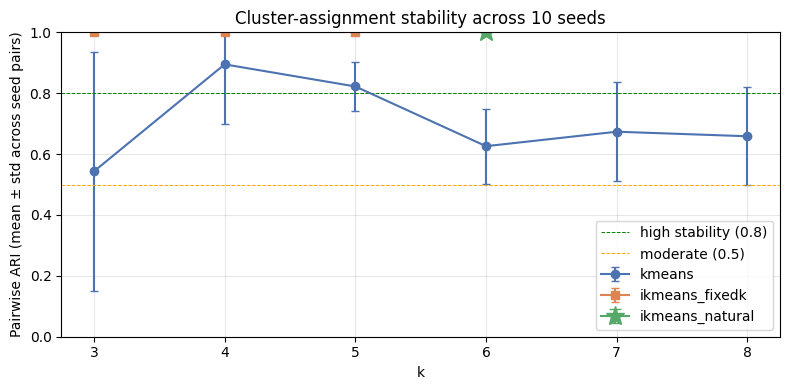

In [50]:
# Visualise stability
fig, ax = plt.subplots(figsize=(8, 4))
if not ari_km.empty:
    ax.errorbar(ari_km['k'], ari_km['ari_mean'], yerr=ari_km['ari_std'],
                marker='o', label='kmeans', color='#4C72B0', capsize=3)
if not ari_ik.empty:
    ax.errorbar(ari_ik['k'], ari_ik['ari_mean'], yerr=ari_ik['ari_std'],
                marker='s', label='ikmeans_fixedk', color='#DD8452', capsize=3)
if not ari_in.empty:
    ax.errorbar(ari_in['k'], ari_in['ari_mean'], yerr=ari_in['ari_std'],
                marker='*', markersize=14, label='ikmeans_natural',
                color='#55A868', capsize=4)
ax.axhline(0.8, color='green', linestyle='--', linewidth=0.7, label='high stability (0.8)')
ax.axhline(0.5, color='orange', linestyle='--', linewidth=0.7, label='moderate (0.5)')
ax.set_xlabel('k')
ax.set_ylabel('Pairwise ARI (mean ± std across seed pairs)')
ax.set_title('Cluster-assignment stability across 10 seeds')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig('plots/stability_ari.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Experiment logging and repository status (continued)

### 7.1 `experiments.csv` — preview

The schema and helper were defined before Section 5; all baseline runs now sit in this file.

In [51]:
exp_preview = pd.read_csv(EXPERIMENTS_PATH)
print(f'experiments.csv has {len(exp_preview)} rows.')
print(f'Columns: {list(exp_preview.columns)}')
print('\nFirst 6 rows:')
display_cols = ['run_id', 'timestamp', 'method', 'k', 'seed',
                'silhouette_train', 'davies_bouldin_train', 'runtime_s']
print(exp_preview[display_cols].head(6).to_string(index=False))

experiments.csv has 220 rows.
Columns: ['run_id', 'timestamp', 'representation_id', 'method', 'parameters', 'seed', 'k', 'sample_rule', 'n_train', 'n_val', 'silhouette_train', 'davies_bouldin_train', 'calinski_harabasz_train', 'silhouette_val', 'davies_bouldin_val', 'calinski_harabasz_val', 'runtime_s', 'notes']

First 6 rows:
  run_id                 timestamp method  k  seed  silhouette_train  davies_bouldin_train  runtime_s
5eefdc29 2026-04-30T15:57:49+00:00 kmeans  3 17341            0.0790                2.6567      0.301
0971e426 2026-04-30T15:57:50+00:00 kmeans  3 17342            0.0885                2.7293      0.303
bc0050ca 2026-04-30T15:57:51+00:00 kmeans  3 17343            0.0784                2.6567      0.229
80d65536 2026-04-30T15:57:52+00:00 kmeans  3 17344            0.0795                2.6520      0.188
28f7a15c 2026-04-30T15:57:53+00:00 kmeans  3 17345            0.0794                2.6574      0.252
52fd99de 2026-04-30T15:57:53+00:00 kmeans  3 17346         

### 7.2 Environment and entry point

- **`environment.yml` / `requirements.txt`:** _[fill in: yes — committed at repo root, generated via `pip freeze` / `conda env export`]_
- **Run command / entry point:** _[fill in: `python -m project.run_all` or `jupyter nbconvert --execute milestone_2.ipynb`]_
- **Modules used by this notebook:**
  - `ikmeans.py` — anomalous-pattern initialisation (Mirkin), spec-compliant.
  - `experiments.csv` — append-only experiment log.
  - `artifacts/rep_v1_with_hotel.json`, `artifacts/rep_v3_no_hotel.json` — representation specs.

## Appendix

The suggested appendix items are inlined throughout the notebook:

| Item | Where |
|---|---|
| Feature-selection table | Section 4.1 |
| ColumnTransformer / Pipeline sketch | Section 4 (preprocessing cell) |
| Missingness table | Section 3.1 |
| Outlier table | Section 3.2 |
| Baseline-results table (k-means + iK-means) | Section 5.6 |
| `experiments.csv` excerpt | Section 7.1 |
| Cluster-profile table | Section 5.8 |
| Stability (ARI) figure | Section 6.5 |

Plots saved to `plots/`: `baseline_metrics_comparison.png`, `stability_ari.png`.

Artefacts saved to `artifacts/`: `rep_v1_with_hotel.json`, `rep_v3_no_hotel.json`.

Long-form data documentation, EDA narratives, and pairwise-association heatmaps remain in the Milestone 1 notebook (`main.ipynb`).